# Data Visualization

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

In [78]:
df = pd.read_csv("data/cleaned_hotel_reservations_v1.csv")
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0,Room_Type 1,48,Online,0,0,0,94.50,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25390,2,2,0,1,Meal Plan 1,0,Room_Type 6,0,Online,0,0,0,216.00,0,1
25391,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,Online,0,0,0,167.80,1,0
25392,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,Online,0,0,0,90.95,2,1
25393,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,Online,0,0,0,98.39,2,0


---

## Correlation Heatmap

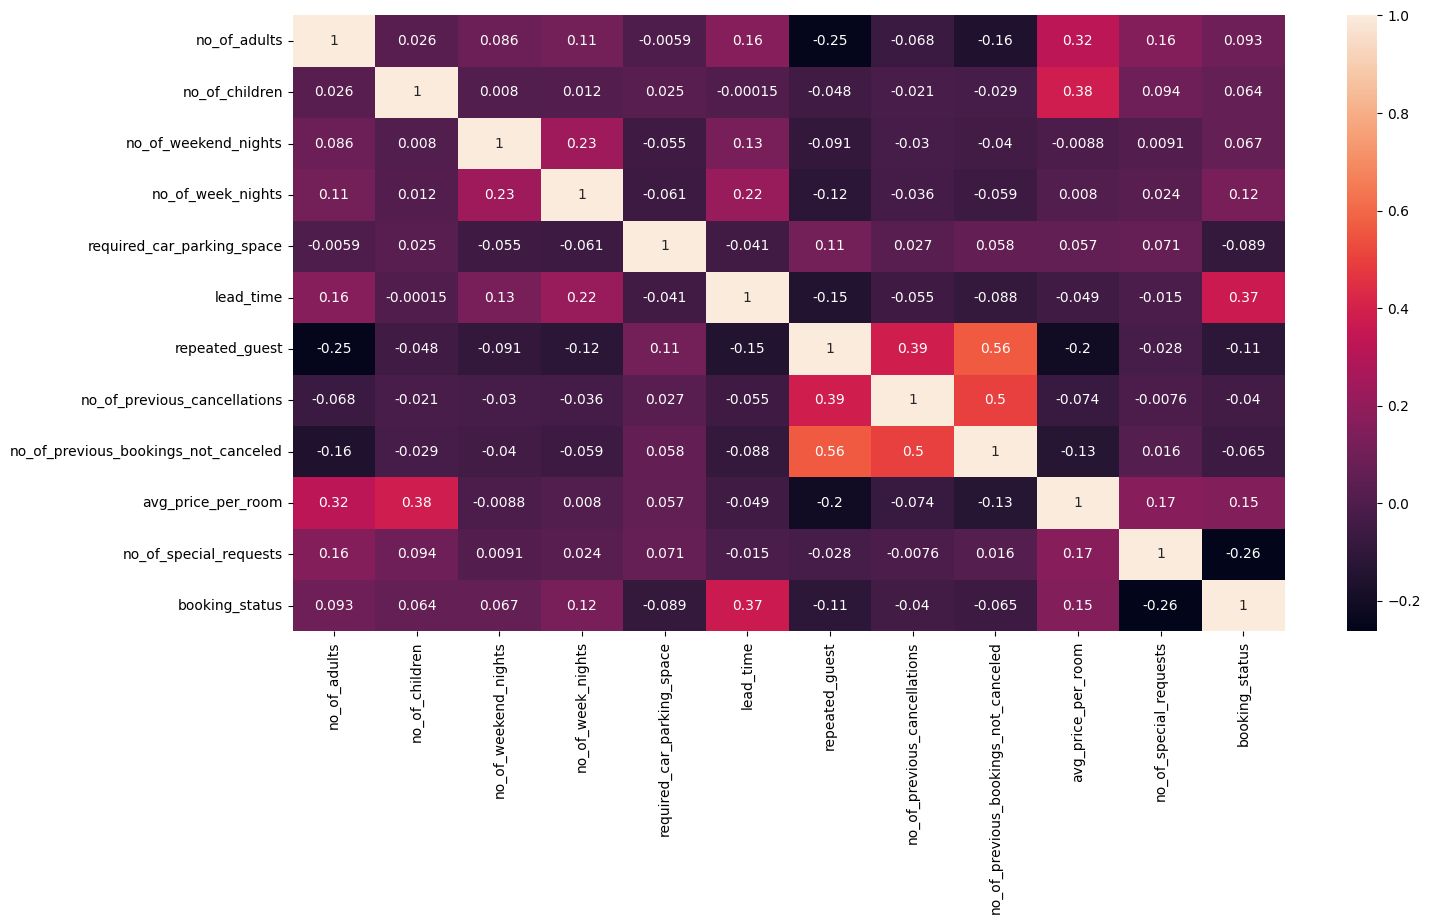

In [79]:
import seaborn as sn

plt.figure(figsize=(16,8))
sn.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

- Seeing the corr. heatmap, the biggest factor affecting the booking_status is the lead_time(the time in days between the booking and arrival). As the time increses, customers are more likely to cancel the reservation.
- And you can also notice the corr. between special requests and booking status is negative. Meaning that those customers who have some special requests are less likely to cancel.
- As no. of adults and children increases, the avg room price also increases. Which is kind of obvious.
- Repeated guests have a stronger relationship with "not" cancelling the reservation, than with cancelling the reservations. Their relationshop is negative with booking_status, meaning they are less likely to cancel the reservation.

---

## Pie Chart of Booking Status

In [80]:
df["booking_status"].value_counts()

booking_status
0    18038
1     7357
Name: count, dtype: int64

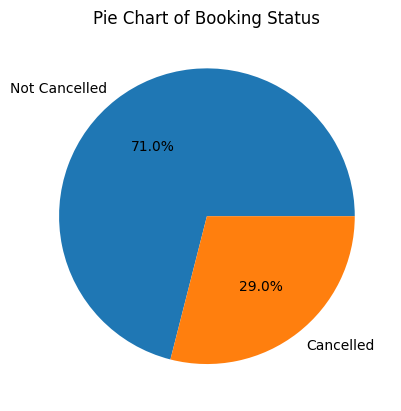

In [91]:
plt.pie(df["booking_status"].value_counts(),
        labels=["Not Cancelled", "Cancelled"], autopct="%1.1f%%")
plt.title("Pie Chart of Booking Status")
plt.show()

The data we have contains 71% of customers who didn't cancel their reservations. While 29% did cancel their reservations.

---

## Lead Time vs Booking Status

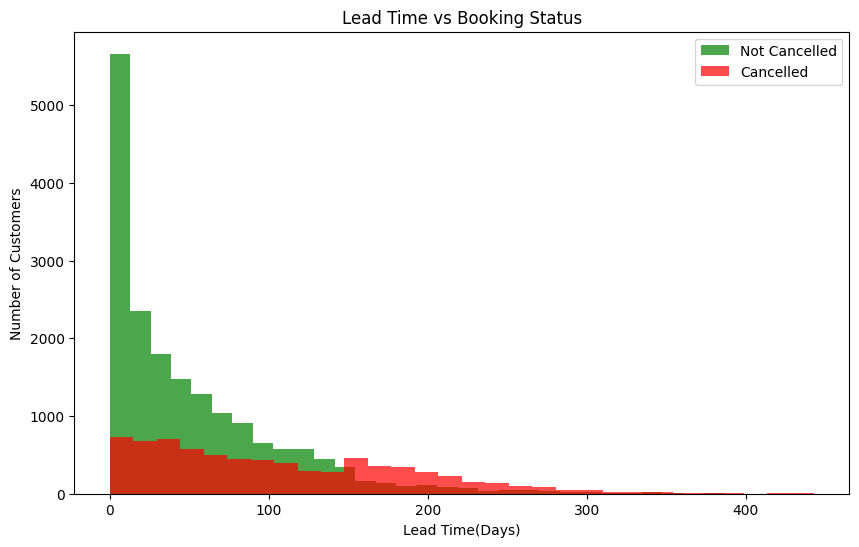

In [82]:
plt.figure(figsize=(10, 6))
plt.hist(df[df["booking_status"] == 0]["lead_time"], bins=30, alpha=0.7, color="green", label="Not Cancelled")
plt.hist(df[df["booking_status"] == 1]["lead_time"], bins=30, alpha=0.7, color="red", label="Cancelled")
plt.xlabel("Lead Time(Days)")
plt.ylabel("Number of Customers")
plt.title("Lead Time vs Booking Status")
plt.legend()
plt.show()

It is clearly visualizing our last claim that the the customers with low lead time are less likely to cancel their reservations.

---

## Bar chart of Cancellation Rate Per Market Segment Type

Market segment refers to how the customer made the booking.

In [83]:
bar_seg_type = df.groupby("market_segment_type")["booking_status"].mean()*100
bar_seg_type

market_segment_type
Aviation         22.916667
Complementary     0.000000
Corporate         9.852599
Offline          12.103175
Online           34.177601
Name: booking_status, dtype: float64

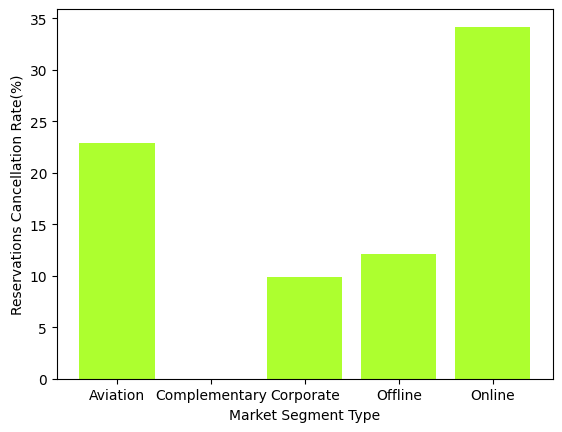

In [84]:
plt.bar(bar_seg_type.index, bar_seg_type.values, color = "greenyellow")
plt.xlabel("Market Segment Type")
plt.ylabel("Reservations Cancellation Rate(%)")
plt.show()

- Complementary reservations given to customers have the the lowest rate of cancellation. Who would want to miss a free stay? LOL
- Bookings made Online have the highest rate of cancellation. I can relate with this online booking this:)
- Bookings made by companies for their employees have the second lowest rate of cancellation. It makes sense cause why the company would cancel the reservations for their employees if they are there for the company's own benefit. Unless the deal or whatever the employee is their make, cancels.
- Aviation bookings are the one that are made for airline crews for overnight stays, having the second highest rate of cancellation. Reasons could be change in the flight time, flight cancellation, etc.

---

## Special Requests vs Booking Status

In [85]:
print(df["no_of_special_requests"].unique())
special_req = df.groupby("no_of_special_requests")["booking_status"].mean()*100
special_req

[0 1 3 2 4 5]


no_of_special_requests
0    41.753420
1    21.256454
2    13.876478
3     0.000000
4     0.000000
5     0.000000
Name: booking_status, dtype: float64

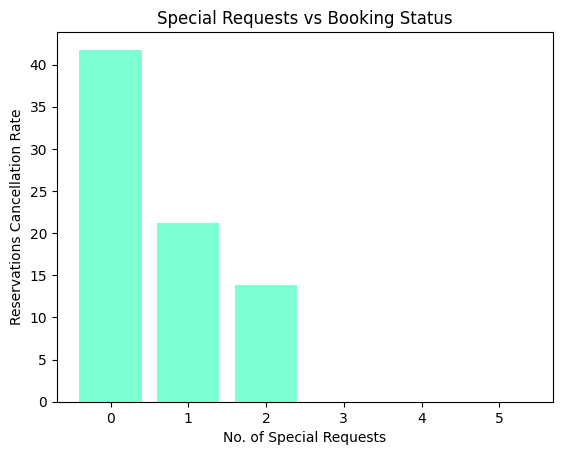

In [86]:
plt.bar(special_req.index, special_req.values, color="aquamarine")
plt.xlabel("No. of Special Requests")
plt.ylabel("Reservations Cancellation Rate")
plt.title("Special Requests vs Booking Status")
plt.show()

It also confirms our previous claim : the more the special requests, the less likely the customer is to cancel the reservation. We can also see that customers with more than 2 special requests have zero cancellation rate.

---

## Average Room Price vs Number of Adults

In [92]:
print(df["no_of_adults"].unique())
num_of_adults = df.groupby("no_of_adults")["avg_price_per_room"].mean()
num_of_adults

[2 1 3 4]


no_of_adults
1     90.123110
2    105.902242
3    142.885456
4    188.052500
Name: avg_price_per_room, dtype: float64

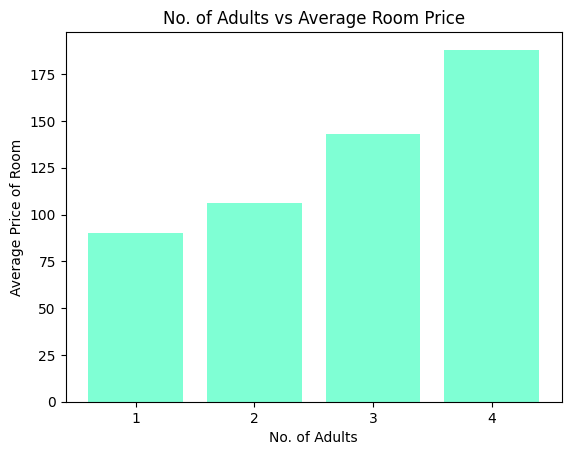

In [93]:
plt.bar(num_of_adults.index, num_of_adults.values, color="aquamarine")
plt.xlabel("No. of Adults")
plt.ylabel("Average Price of Room")
plt.title("No. of Adults vs Average Room Price")
plt.xticks([1,2,3,4])
plt.show()

As the number of adults increases, the average price of the room also increases. Makes total sense as more people need more space, which costs more money.

---

## Repeated Customers vs Cancellation Rate

In [89]:
print(df["repeated_guest"].unique())
repeated_customers = df.groupby("repeated_guest")["booking_status"].mean()*100
repeated_customers

[0 1]


repeated_guest
0    29.903956
1     1.093560
Name: booking_status, dtype: float64

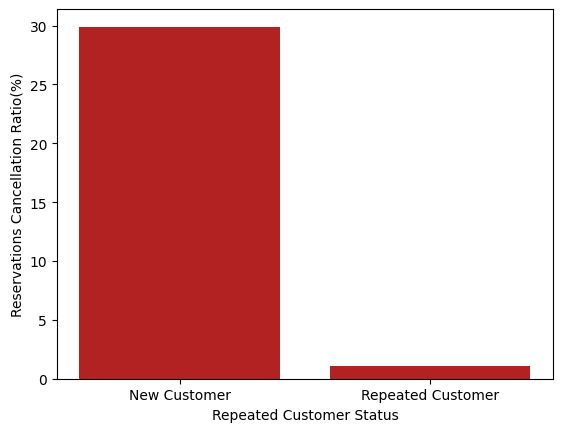

In [90]:
plt.bar(repeated_customers.index, repeated_customers.values, color = "firebrick")
plt.xlabel("Repeated Customer Status")
plt.ylabel("Reservations Cancellation Ratio(%)")
plt.xticks([0, 1], ["New Customer", "Repeated Customer"])
plt.show()

New customers have far higher chances of cancelling their reservations as compared to repeated customers. Suggesting that the repeated customers are very much satisfied with the services of the hotel.

---